# Analysis of Humanitarian Funding vs. Crisis Severity

## What is the INFORM Severity Index?
(Based on INFORM Severity Index User Guide v01, October 2020)

The INFORM Severity Index is a composite indicator designed to measure the severity of humanitarian crises globally against a common scale. It is intended to support decision-makers by providing an objective, shared understanding of crisis severity to guide resource allocation.

The index aggregates data from credible, publicly available sources (UN agencies, governments, multilateral organizations) and evaluates severity based on three core dimensions:
1. **Impact of the Crisis**: The scope of its geographical, human, and physical effects.
2. **Conditions of People Affected**: The status of the affected population, including the distribution of severity categories.
3. **Complexity of the Crisis**: Factors that affect the mitigation or resolution of the crisis, such as humanitarian access and rule of law.

Each crisis is scored on a scale from **0 to 5**:
- **0.0 - 1.9**: Very Low
- **2.0 - 2.9**: Low
- **3.0 - 3.9**: Medium
- **4.0 - 4.9**: High
- **5.0**: Very High

This notebook analyzes whether actual financial allocations (from CERF and CBPF) align with this objective measure of severity.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# Configuration: Clean, standard, no custom aesthetics
plt.style.use('default') 
sns.set_style('whitegrid')
sns.set_context('notebook')

# Standard colors
COLOR_BLUE = '#1f77b4'
COLOR_RED = '#d62728'


In [2]:
# Load dataset
df = pd.read_csv('../data/geo_mismatch/country_year_severity_funding.csv')

# Filter for relevant years (2020-2025) and valid funding data
df = df[df['Year'] >= 2020].copy()

# Ensure we have numeric data
df['Total_Actual_Funding'] = pd.to_numeric(df['Total_Actual_Funding'], errors='coerce').fillna(0)
df['revisedRequirements'] = pd.to_numeric(df['revisedRequirements'], errors='coerce').fillna(0)

# Create a subset of data that actually has funding or needs for cleaner plotting
# (Removing rows with 0 funding AND 0 severity to reduce "empty space")
plot_df = df[(df['INFORM Severity Index'] > 0) & ((df['Total_Actual_Funding'] > 0) | (df['revisedRequirements'] > 0))].copy()

print(f"Data loaded: {len(plot_df)} records for analysis.")


Data loaded: 345 records for analysis.


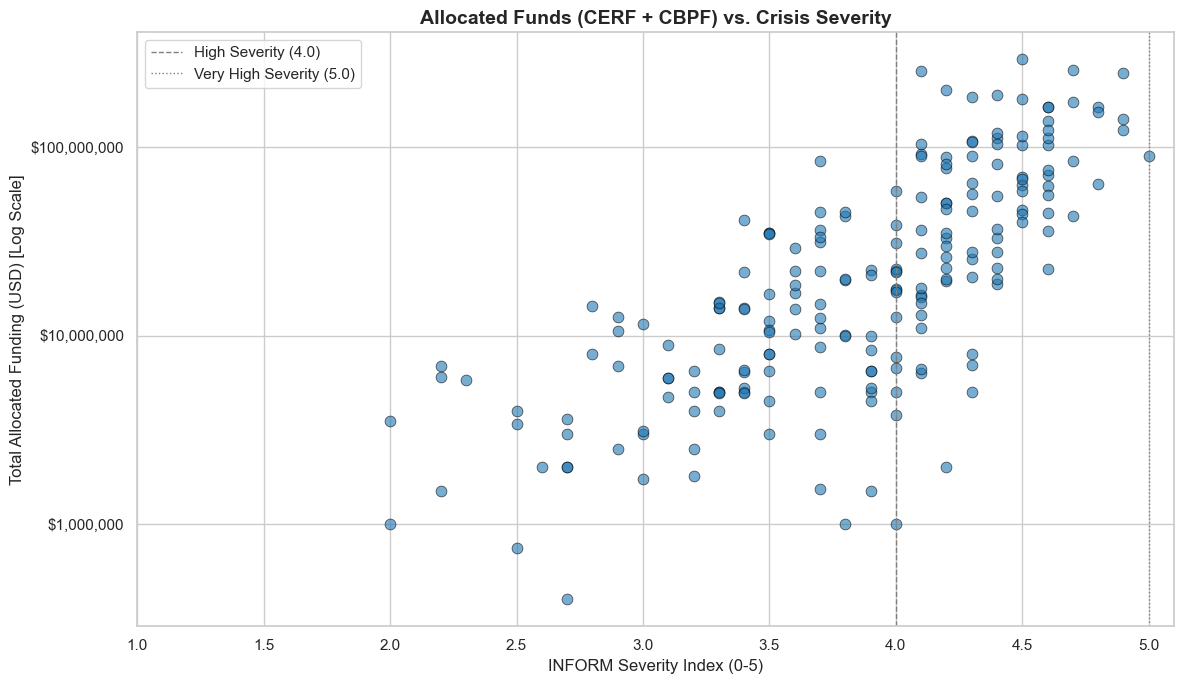

In [3]:
plt.figure(figsize=(12, 7))

# Plot: Severity (X) vs Allocated Funds (Y)
# Use log scale for funds because they span orders of magnitude ($100k to $1B)
sns.scatterplot(
    data=plot_df,
    x='INFORM Severity Index',
    y='Total_Actual_Funding',
    alpha=0.6,
    s=60,
    color=COLOR_BLUE,
    edgecolor='k'
)

plt.yscale('log')
plt.title('Allocated Funds (CERF + CBPF) vs. Crisis Severity', fontsize=14, fontweight='bold')
plt.xlabel('INFORM Severity Index (0-5)', fontsize=12)
plt.ylabel('Total Allocated Funding (USD) [Log Scale]', fontsize=12)

# Format Y axis as currency
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '${:,.0f}'.format(y)))

# Add severity thresholds
plt.axvline(x=4.0, color='gray', linestyle='--', linewidth=1, label='High Severity (4.0)')
plt.axvline(x=5.0, color='gray', linestyle=':', linewidth=1, label='Very High Severity (5.0)')

# Tighter limits to remove empty space
plt.xlim(plot_df['INFORM Severity Index'].min() - 0.1, 5.1)
plt.legend()
plt.tight_layout()
plt.show()


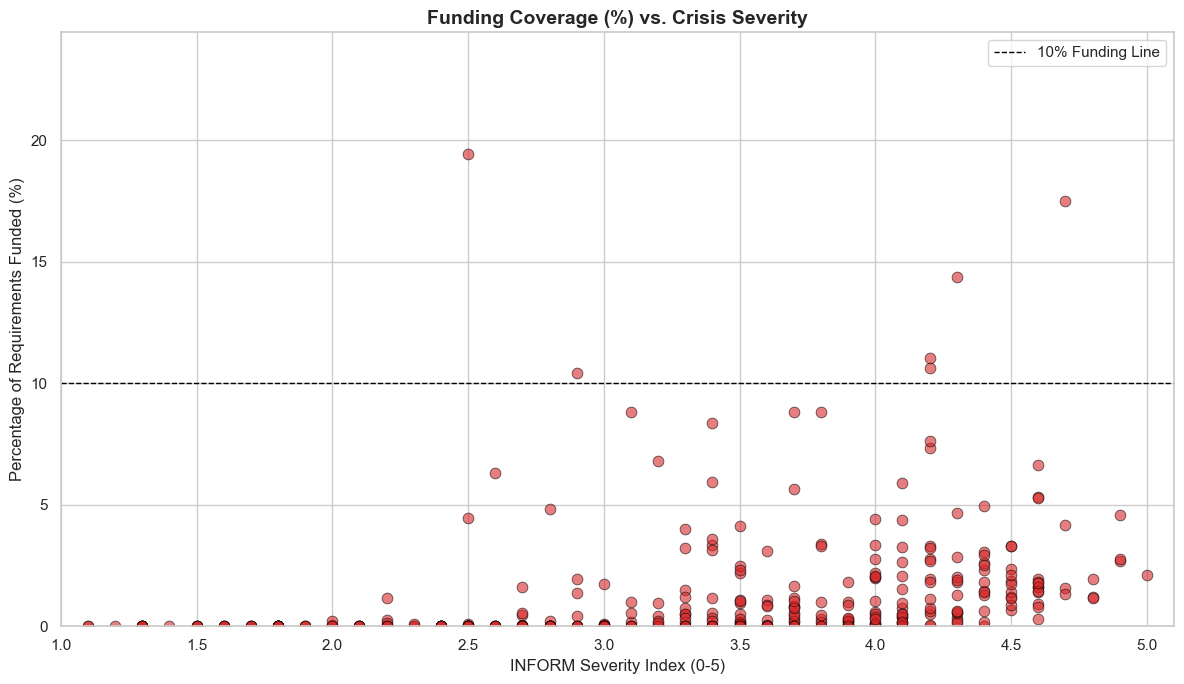

In [4]:
plt.figure(figsize=(12, 7))

# Filter out tiny requirements to avoid noise in percentages
coverage_df = plot_df[plot_df['revisedRequirements'] > 1_000_000].copy()

sns.scatterplot(
    data=coverage_df,
    x='INFORM Severity Index',
    y='Pct_Funded',
    alpha=0.6,
    s=60,
    color=COLOR_RED,
    edgecolor='k'
)

plt.title('Funding Coverage (%) vs. Crisis Severity', fontsize=14, fontweight='bold')
plt.xlabel('INFORM Severity Index (0-5)', fontsize=12)
plt.ylabel('Percentage of Requirements Funded (%)', fontsize=12)

# Reference line at 10%
plt.axhline(y=10, color='black', linestyle='--', linewidth=1, label='10% Funding Line')

# Tighter scale - focus on the main distribution, cut off extreme outliers > 100% if distinct
plt.ylim(0, min(105, coverage_df['Pct_Funded'].max() + 5))
plt.xlim(coverage_df['INFORM Severity Index'].min() - 0.1, 5.1)

plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Identification of High Severity (>=4.0) crises with Low Funding (<$5M)
# This highlights direct lack of resources, not just percentage.

high_severity = plot_df[plot_df['INFORM Severity Index'] >= 4.0]
low_funds = high_severity[high_severity['Total_Actual_Funding'] < 5_000_000].sort_values('INFORM Severity Index', ascending=False)

print("Severe Crises (Severity >= 4.0) with Less Than $5M allocated funds:")
display_cols = ['Country_ISO3', 'Year', 'INFORM Severity Index', 'Total_Actual_Funding', 'revisedRequirements']
low_funds[display_cols].head(15).style.format({
    'Total_Actual_Funding': '${:,.0f}',
    'revisedRequirements': '${:,.0f}',
    'INFORM Severity Index': '{:.2f}'
})


Severe Crises (Severity >= 4.0) with Less Than $5M allocated funds:


,Country_ISO3,Year,INFORM Severity Index,Total_Actual_Funding,revisedRequirements
233,PSE,2024,4.40,$0,"$10,268,567,802"
59,CMR,2021,4.30,"$4,998,919","$1,446,217,260"
5,LBY,2020,4.20,$0,"$1,859,692,010"
63,COL,2021,4.20,"$2,006,312","$3,226,489,430"
11,VEN,2020,4.10,$0,"$1,562,509,363"
238,COL,2024,4.10,$0,"$3,838,839,332"
13,CAF,2020,4.00,"$1,000,994","$1,353,622,290"
240,CAF,2024,4.00,$0,"$872,222,915"
242,PAK,2024,4.00,$0,"$1,240,769,268"
309,CMR,2025,4.00,$0,"$1,437,193,312"


# Data Quality & Cleaning Methodology (INFORM Severity Index)

This section documents the preprocessing steps applied to the `inform_severity_master_2020_2025.csv` dataset. The raw data contained formatting inconsistencies and metadata rows that required cleaning before analysis.

### 1. Initial Assessment & Issues
*   **Metadata Artifacts**: The dataset is a concatenation of yearly reports, resulting in repeated headers and non-data rows (e.g., "Weights", "(a-z)", "(1-5)").
*   **Missing Values**: Missing numerical scores were denoted by 'x' instead of standard `NaN`.
*   **Data Types**: Numerical columns were initially interpreted as objects due to these artifacts.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Define Paths
DATA_DIR = Path('../data/geo_mismatch')
RAW_PATH = DATA_DIR / 'inform_severity_master_2020_2025.csv'
CLEAN_PATH = DATA_DIR / 'inform_severity_cleaned.csv'

def clean_inform_data(raw_path, output_path):
    print("Loading raw data...")
    try:
        df = pd.read_csv(raw_path)
    except FileNotFoundError:
        print(f"File not found: {raw_path}")
        return

    initial_rows = len(df)
    
    # 1. Remove Metadata Rows
    # Regex to identify non-data rows based on 'CRISIS' column patterns
    garbage_mask = df['CRISIS'].astype(str).str.contains(r'Weights|\(a-z\)|\(1-5\)|\(Very Low-Very High\)|^\d+$', regex=True, na=False)
    garbage_mask |= df['CRISIS'].astype(str).isin(['False', 'nan', '0'])
    df_clean = df[~garbage_mask].copy()
    
    print(f"Removed {initial_rows - len(df_clean)} metadata rows.")

    # 2. Handle Missing Values ('x') & Convert Types
    score_cols = [
        'INFORM Severity Index', 'Impact of the crisis', 'Geographical Impact', 'Human Impact',
        'Conditions of people affected', 'People in need', 'Concentration of conditions',
        'Complexity of the crisis', 'Society and safety', 'Operating environment'
    ]
    
    for col in score_cols:
        if col in df_clean.columns:
            # Coerce errors to NaN (handles 'x')
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            
    # 3. Standardize Years & Dates
    if 'Year' in df_clean.columns:
        df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce').fillna(0).astype(int)
    if 'Last updated' in df_clean.columns:
        df_clean['Last updated'] = pd.to_datetime(df_clean['Last updated'], errors='coerce')
        
    # 4. Export
    df_clean.to_csv(output_path, index=False)
    print(f"Cleaned dataset saved to {output_path} ({len(df_clean)} rows).")
    return df_clean

# Execute Cleaning
# df_cleaned = clean_inform_data(RAW_PATH, CLEAN_PATH)

In [ ]:
# Validation Check
if CLEAN_PATH.exists():
    df_validation = pd.read_csv(CLEAN_PATH)
    print("Validation Summary:")
    print(f"- Shape: {df_validation.shape}")
    print(f"- Missing Values (INFORM Index): {df_validation['INFORM Severity Index'].isnull().sum()}")
    print(f"- Unique Years: {sorted(df_validation['Year'].unique())}")
    print("- Data Types:\n", df_validation[['INFORM Severity Index', 'Year']].dtypes)